In [1]:
%load_ext autoreload
%autoreload 2

#%matplotlib ipympl

import numpy as np
import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
from skimage.transform import iradon

maptools.job.info()
maptools.plot.dark()
!which python

import h5py
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.point_by_point
import matplotlib.pyplot as plt
import numpy as np

hostname: n-62-11-21
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 24
Memory available: 775.19613952 GB
~/miniconda3/envs/textom/bin/python


In [2]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/strong_pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)
colf.updateGeometry()

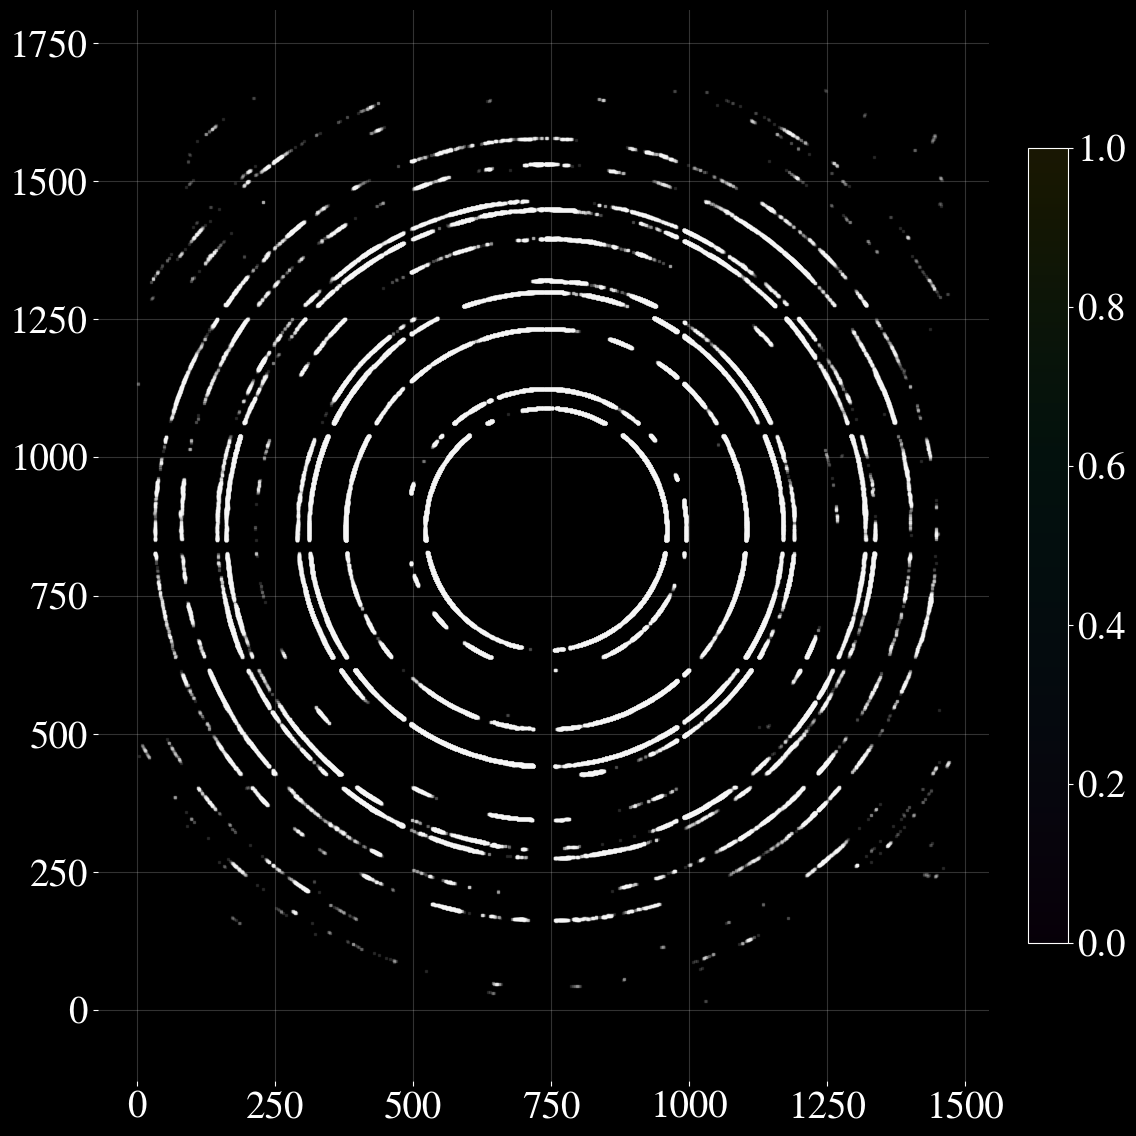

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
im = ax.scatter(colf.fc[colf.omega < 5], colf.sc[colf.omega < 5], marker=",", s=1, alpha=0.1, c='w')
fig.colorbar(im, ax=ax, fraction=0.041, pad=0.04)
ax.grid(True, alpha=0.2)
plt.axis("equal")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
a = colf.parameters.parameters["cell__a"]
b = colf.parameters.parameters["cell__b"]
c = colf.parameters.parameters["cell__c"]
alpha = colf.parameters.parameters["cell_alpha"]
beta = colf.parameters.parameters["cell_beta"]
gamma = colf.parameters.parameters["cell_gamma"]
symmetry = colf.parameters.parameters["cell_lattice_[P,A,B,C,I,F,R]"]
lattice_parameters = [a, b, c, alpha, beta, gamma]
ucell = ImageD11.unitcell.unitcell(lattice_parameters, symmetry)
ucell.makerings(colf.ds.max())

indexer = ImageD11.indexing.indexer_from_colfile(colf)
print(f"Indexing {colf.nrows} peaks")
indexer_ds_tol = 0.01
indexer.ds_tol = indexer_ds_tol

ImageD11.indexing.loglevel = 1
indexer.assigntorings()
ImageD11.indexing.loglevel = 3

info: gv: [[-0.26029091 -0.62463564  1.00158719]
 [-0.21694844  0.47220544  0.97352856]
 [-0.03250545 -0.327325    0.27251693]
 ...
 [-0.33307446  1.2739239   0.17562974]
 [-0.33290722  1.27414265  0.17159008]
 [-0.33179847  1.27187041  0.17300025]] (44189043, 3) float64
Indexing 44189043 peaks
info: Assign to rings, maximum d-spacing considered: 1.843150
info: Ring assignment array shape (44189043,)
info: Ring     (  h,  k,  l) Mult  total indexed to_index  ubis  peaks_per_ubi   tth
info: Ring 19  ( -2, -6, -4)   48      3       0        3     0     96  38.40
info: Ring 18  ( -4, -6,  0)   24      6       0        6     0     48  36.95
info: Ring 17  ( -7, -1, -1)   48     26       0       26     0     96  36.58
info: Ring 16  ( -4, -4, -4)    8     29       0       29     1     16  35.45
info: Ring 15  ( -2, -2, -6)   24    723       0      723    15     48  33.89
info: Ring 14  ( -3, -5, -3)   24   1489       0     1489    30     48  33.50
info: Ring 13  (  0, -6, -2)   24   3680   

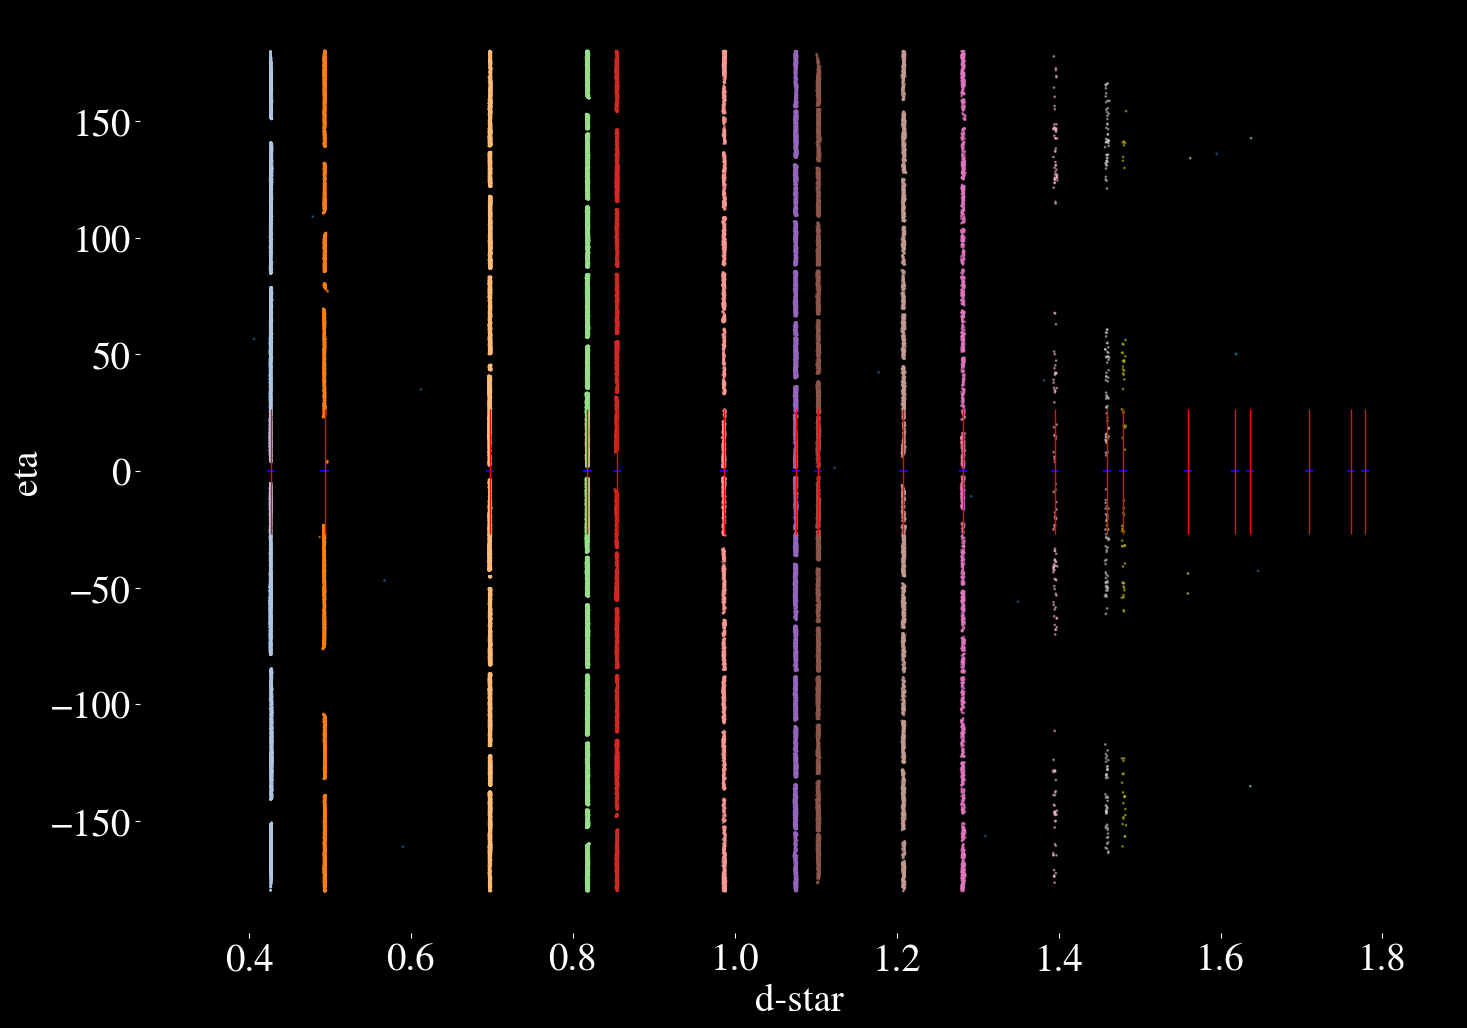

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(17, 12))
sample = np.random.permutation(colf.nrows)[:100000]
ax.scatter(colf.ds[sample], colf.eta[sample], c=indexer.ra[sample], cmap="tab20", s=1, alpha=0.5)
ds_tol = 0.01

for ucr in ucell.ringds:
    ax.hlines( 0, ucr-ds_tol/2., ucr +ds_tol/2., color="blue")

ax.plot(
    ucell.ringds,
    [
        0,
    ]
    * len(ucell.ringds),
    "|",
    ms=90,
    c="red",
)
ax.set_xlabel("d-star")
ax.set_ylabel("eta")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(colf.ds.min() - 0.05, colf.ds.max() + 0.05)
plt.show()

In [6]:
sample = np.random.permutation(colf.nrows)[:1000000]

cf = {
      'sc' : colf.sc[sample],
      'fc': colf.fc[sample],
      'sum_intensity': colf.sum_intensity[sample],
      'Number_of_pixels': colf.Number_of_pixels[sample],
      'omega': colf.omega[sample], 
      'dty': colf.dty[sample] 
     }

cf = ImageD11.columnfile.colfile_from_dict(cf)
params = ImageD11.parameters.read_par_file(parpath)
cf.setparameters(params)
cf.updateGeometry()

cf.filter(np.abs(cf.eta) > 10)
cf.filter(np.abs(cf.eta) < 170)

cf.nrows

885924

In [7]:
downsample_factor = 1000000 / colf.nrows
downsample_factor

0.02263004428495996

In [8]:
ImageD11.indexing.loglevel = -1

indexer = ImageD11.indexing.indexer_from_colfile(cf)
indexer.ds_tol = 0.01
indexer.assigntorings()
indexer.cosine_tol = np.cos(np.radians(90 - maptools.constants.OMEGASTEP * 1.5))
indexer.ring_1 = 0
indexer.ring_2 = 1
indexer.max_grains = 50

average_grain_diameter = 9
average_omega_peak_split = 5
everage_eta_peak_split = 3
expected_peaks = (6 + 8) * average_grain_diameter * downsample_factor * average_omega_peak_split * everage_eta_peak_split

frac = 0.8

indexer.hkl_tol = 0.03
indexer.minpks = int(expected_peaks * frac)

print("minpks", indexer.minpks)

indexer.find()  # finds trial orientations

info: gv: [[-0.43258926  0.09305127  0.98043519]
 [ 0.04719491  0.21637522  0.66027707]
 [ 0.02152436  0.40117153  0.71101354]
 ...
 [ 0.78225163  0.18085324  0.15819923]
 [-0.00636694  0.70635535  0.4145425 ]
 [-0.17410634  0.54512493  0.39911915]] (885924, 3) float64
info: Assign to rings, maximum d-spacing considered: 1.760839
info: Ring assignment array shape (885924,)
info: Ring     (  h,  k,  l) Mult  total indexed to_index  ubis  peaks_per_ubi   tth
info: Ring 17  ( -1, -7, -1)   48      1       0        1     0     96  36.58
info: Ring 16  ( -4, -4, -4)    8      1       0        1     0     16  35.45
info: Ring 15  ( -6, -2, -2)   24     12       0       12     0     48  33.89
info: Ring 14  ( -5, -3, -3)   24     37       0       37     0     48  33.50
info: Ring 13  ( -2,  0, -6)   24     81       0       81     1     48  32.27
info: Ring 12  (  0, -6,  0)   30    853       0      853    14     60  30.57
info: Ring 11  ( -5, -1, -3)   48   2320       0     2320    24     96 

In [9]:
indexer.scorethem()  # scores them trial orientations
np.sum(indexer.scores), len(indexer.ubis), indexer.scores

info: Scoring 138934 potential orientations
info: new grain 399 pks, i 885913 j 849965 UBI  -0.879711 3.601206 -1.639795 -3.300007 -1.595222 -1.728441 -2.179846 0.959604 3.281877
info: new grain 201 pks, i 885912 j 130118 UBI  -1.503466 -3.719154 -0.580091 -1.225004 -0.109483 3.864591 -3.558280 1.607923 -1.081365
info: new grain 1259 pks, i 885889 j 228528 UBI  0.904883 -3.579477 -1.673024 -3.428237 0.143859 -2.159661 1.965859 1.896506 -2.996022
info: new grain 432 pks, i 885881 j 282727 UBI  -2.998898 2.685823 0.455973 0.127571 0.811921 -3.970687 -2.724753 -2.923296 -0.687713
info: new grain 321 pks, i 885880 j 648623 UBI  -0.953159 2.163227 -3.293801 2.193903 3.102223 1.406486 3.273495 -1.451839 -1.901870
info: new grain 776 pks, i 885878 j 430879 UBI  -3.443559 -1.005795 1.890408 -2.046446 2.604180 -2.338394 -0.636583 -2.939260 -2.718215
info: new grain 345 pks, i 885876 j 615679 UBI  -2.462673 -0.511375 3.178538 2.688291 -2.524260 1.688644 1.760842 3.135190 1.867090
info: new grain

(np.int64(24995),
 50,
 [399,
  201,
  1259,
  432,
  321,
  776,
  345,
  369,
  517,
  415,
  354,
  355,
  436,
  255,
  661,
  481,
  406,
  395,
  448,
  347,
  488,
  321,
  501,
  1245,
  426,
  445,
  449,
  348,
  527,
  604,
  426,
  342,
  342,
  402,
  391,
  887,
  316,
  491,
  536,
  289,
  856,
  351,
  307,
  873,
  428,
  370,
  334,
  972,
  960,
  596])

In [10]:
indexer.ubis

[array([[-0.87971051,  3.6012063 , -1.63979524],
        [-3.3000071 , -1.59522187, -1.72844104],
        [-2.17984587,  0.95960421,  3.28187723]]),
 array([[-1.50346629, -3.71915438, -0.58009148],
        [-1.22500382, -0.10948266,  3.86459125],
        [-3.55827953,  1.60792325, -1.08136483]]),
 array([[ 0.90488315, -3.57947722, -1.67302351],
        [-3.42823739,  0.14385901, -2.15966135],
        [ 1.96585858,  1.89650621, -2.99602218]]),
 array([[-2.99889817,  2.68582314,  0.45597263],
        [ 0.1275705 ,  0.81192128, -3.97068702],
        [-2.72475301, -2.92329597, -0.68771338]]),
 array([[-0.95315933,  2.1632269 , -3.29380107],
        [ 2.19390251,  3.10222309,  1.40648597],
        [ 3.27349496, -1.45183875, -1.90187032]]),
 array([[-3.44355942, -1.00579473,  1.89040828],
        [-2.04644572,  2.60417975, -2.33839446],
        [-0.63658308, -2.93925953, -2.71821479]]),
 array([[-2.46267348, -0.51137534,  3.17853773],
        [ 2.68829146, -2.52426006,  1.68864382],
        

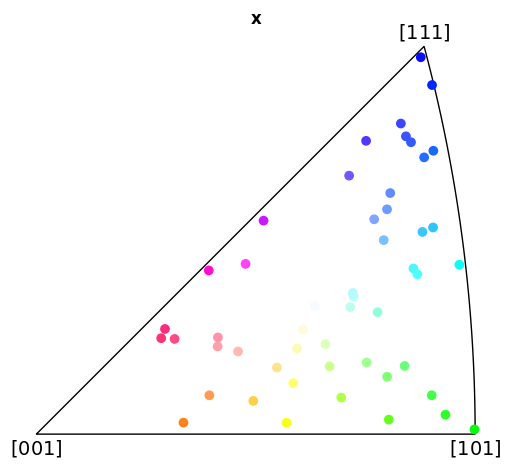

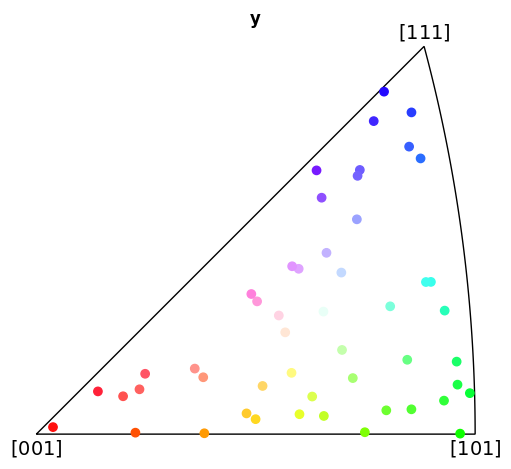

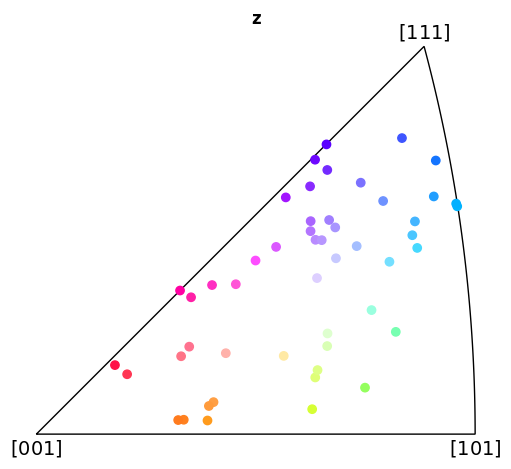

In [11]:
from ImageD11.nbGui import nb_utils as utils

grains = [ImageD11.grain.grain(ubi) for ubi in indexer.ubis]
for g in grains:
    g.ref_unitcell = ucell
plt.style.use("default")
utils.plot_all_ipfs(grains)
plt.show()